Først en lite kommentar. I denne besvarelsen forklarer jeg tign veldig grunndig (håper ikke det fornærmer noen). Hvis ting er lett er det bare å hoppe over forklaringer:) Jeg gir også flere mulige løsninger på flere av problemene, det er sjelden et fasitsvar. Velg den du mener gir mest mening:)

Det er god practice å importere alle biblioteker øverst i koden.

In [6]:
# For å enkelt jobbe med datasett
import pandas as pd

# For å splitte i trening og test data
from sklearn.model_selection import train_test_split

# For effektiv matte
import numpy as np

# For plotting
import matplotlib.pyplot as plt

# Logisitisk regresjon
from sklearn.linear_model import LogisticRegression

# Confusion matrix
from sklearn.metrics import confusion_matrix

# For å lage et tre
from sklearn.tree import DecisionTreeClassifier

# For å plotte treet
from sklearn import tree

#### 1.

a)

Vi ønsker å lese inn datasettet train.csv. Det er lagret i en csv-fil (comma separated fil). Vi kan bruke pandas sin read_csv() for å lese inn datasettet til en DataFrame. 

In [7]:
df = pd.read_csv("train.csv")

Det lønner seg alltid å printe DataFramen for å se at den ble lastet inn ordentelig og få en forståelse for dataen. Dette kan gjøres på flere måter

In [8]:
print(df)              # printer hele datasetet 
print( df.head() )     # printer toppen av datasettet
print( df.tail() )     # printer bunnen av datasettet

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

b)

Hvis vi ser på kolonnen "age" kan vi se at noen av verdiene er NaN. I kodeverden står NaN for "not a number" og vil i praksis si "denne verdien vet vi ikke". Vi ønsker å "håndtere disse". Dette kan gjøres på flere måter og hvilken som er "best" avhenger av hva du skal gjøre videre.

Den aller letteste måten er å bruke pandas sin dropna(subset=...). Den vil fjerne alle rader der de spesifiserte kolonnene (subset) er NaN. For å fjerne alle rader der age er NaN kan vi skrive:

In [9]:
df = df.dropna(subset=["Age"])

Denne metoden fungerer godt hvis du har mye data og age kolonnen er viktig. 

Vi kan telle antall rader der age er NaN med følgende linje.

In [10]:
antall = df["Age"].isna().sum()
print(f"Antall NaN verdier i Age: {antall}")
print(f"Antall rader i datasettet: {len(df)}")
print(f"Andel NaN-verdier: {antall/len(df):.3f}")

Antall NaN verdier i Age: 0
Antall rader i datasettet: 714
Andel NaN-verdier: 0.000


Hvis du derimot har lite data eller at age kolonnen kun er en av mange verdier du skal se på, er det dumt å fjerne alle rader der age er NaN. I datasetett her er 20% av Age verdiene NaN, det er ganske mange så vi ønsker kanskje istedenfor å gjøre om alle NaN verdiene i Age til noe annet, slik at vi ikke forkaster masse data. Vi kan da for eksempel gjøre om alle NaN verdiene i Age til gjennomsnitt-alderen. 

In [11]:
# Forklaring av syntax:
# df["Age"]            - velger ut kolonnen Age i DataFramen vår
# .fillna()            - bytter ut alle NaN verdier med det vi putter inni parantesene 
# df["Age"].mean()     - finner gjennomsnittet av kolonnen Age

df["Age"] = df["Age"].fillna(df["Age"].mean())

c) 

Vi ønsker å one-hot-encode de kategoriske dataene. Først litt begrepsforklaring 
- Kategorisk data - data som er delt inn i kategorier som "Hund" og "Katt" heller enn tall-verdier. I dataanalyse er det mye lettere å jobbe med tall (av mange grunner, jeg forklarer gjerne:), derfor vil vi gjøre om fra kategorisk til numerisk data. 
- One-hot-encoding - Dette er en måte å gjøre om fra kategorisk til numerisk data, jeg forklarer med et eksempel. La oss si at vi har kategorisk data med kategorier "Hund", "Katt" og "Fisk". Istedenfor å ha ÉN kolonne som enten er "Hund", "Katt" eller "Fisk" har vi TRE kolonner der hver kolonne svarer til én av kategoriene. La oss si at den første er "Hund", den andre "Katt" og den tredje "Fisk". Hvis et datapunkt har kategori "Katt" vil en one-hot-encoding av denne verdien være 0 i kolonne "Hund", 1 i kolonne "Katt" og 0 i kolonne "Fisk". Dette kan være litt tricky å forstå gjennom en forklaring, så anbefaler å printe resultatet under og se hva som har endret seg:)

Jeg velger å bruke kolonenne Pclass og Sex som eksempler. Vi skal altså gjøre disse kolonnene fra kategoriske til numeriske. 

In [12]:
categorical_cols = ["Sex", "Embarked"]     # kolonenne vi vil at skal gjøre numeriske 

# Følgende kommando er en munnfull, her er en forklaring:
# pd.get_dummis gjøre kolonner i datasetet fra kategorisk til one-hot-encoded 
#   df - DataFramen vår 
#   columns - de kolonnene i DataFramen vi vil gjøre fra kategorisk til numerisk 
#   prefix - siden vi nå skal gjøre om én kolonne til flere kolonner må vi gi disse nye navn (siden 
#               flere kolonner ikke kan ha samme navn), prefix gir de ulike nye kolonnene navn som 
#               er det gamle navnet med det vi har puttet inn forran 
#   prefix_sep - står for prefix separator
df = pd.get_dummies(df, columns=categorical_cols, prefix=categorical_cols, prefix_sep='_')

d) 

Vi skal nå velge ut data å bruke i dataanalysen. Jeg velger å bruke kolonnene "Age", "Sex" og "Pclass" til å predikere overlevelse ("Survived").

In [13]:
columns = ["Age", "Sex_female", "Pclass"]    # kolonnene jeg vil velge
# Merk over at "Sex" har endret navn til "Sex_femal" (og "Sex_male") fordi den har blitt one-hot-encoded
#   siden Sex bare har to muligheter (i dette datasettet) trenger vi bare å velge én av dem
#   for kategorier med mer enn to muligheter kan det lønne seg å bruke flere av de nye kolonnene som har 
#   blitt laget av one-hot-encoding

X = df[columns]         # velg kolonnene vi vil bruke til å predikere overlevelse
Y = df["Survived"]      # velg ut "Survived" kolonnene


e) 

Vi skal nå dele dataen inn i trening og test data. Hovedgrunnen til at vi ønsker å gjøre dette er for å unngå overtilpasning. Hvis trening og test dataen er det samme kan modellen få perfekt score ved å bare lære seg dataene. Litt som at du lett kan få toppkaraketer om du vet svaret på alle spørsmålene som kommer på eksamen:) Derfor gir vi modellen en helt ny "eksamen" til slutt, den aldri har sett før, for å teste om den egentlig har lært noe.

Spør meg om dette óg, jeg kan snakke mye om sånt:)

Vi kan enkelt splitte dataen ved hjelp av Scikit-learn (eller Sklearn som pakken heter), som train_test_split().

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, Y)

#### 2.

a) 

Vi skal nå plotte sigmoid funksjonen. Det er flere grunner til at denne er godt egnet til å svare på ja/nei spørsmål:
1. Den gir deg kun verdier mellom 0 og 1. Hvis vi istedenfor bruker lineær regresjon kan vi få vilkårlig store verdier, det gir ikke helt mening for et ja/nei spørsmål. Der vil vi helst kunne dele inn i ja (1) og nei (0).
2. Det er en matematisk "pen" funksjon. Den er kontinuerlig ("du kan tegne den uten å løfte blyanten"). 
3. Det er lett å vite hvor mange skal sette grensa mellom ja og nei. Hvis du putter inn 0, får du 0.5, dette er et veldig naturlig sted å putte skillet mellom ja og nei. 

Vi plotter sigmoid funksjonen. Den har definisjon $\frac{1}{1+e^{-x}}$ 

In [15]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

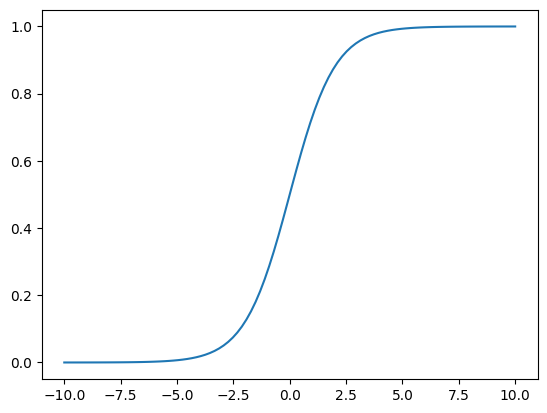

In [16]:
# np.linspace(-10, 10, 100) gir deg 100 tall jevnt fordelt mellom to -10 og 10
x_sigmoid = np.linspace(-10, 10, 100)
# Vi anvender funksjoenen vi definerte over på dataen (merk at siden np.linspace gir en vektor (array),
#      kan vi gjøre matte på hele greia samtidig!)
y_sigmoid = sigmoid(x_sigmoid) 

# plotter sigmoid funksjonen (den har en veldig karakteristisk S form)
plt.plot(x_sigmoid, y_sigmoid) 

b) 

Vi skal nå gjøre logistisk regresjon. Det vil si, finne den S kurven som best predikerer om noen overlever basert på de tre kolonnene vi valge ut over ("Age", "Sex" og "Pclass"). Å trene modellen kan enkelt gjøres ved scikit-learn (Sklearn) sin LogisticRegression.

In [17]:
model = LogisticRegression()  # lage en logistisk regresjons-model 
model.fit(X_train, y_train)   # tren modellen (merke av vi bruker X_train og Y_train)

LogisticRegression()

c) 

Vi ønsker nå å score modellen vår. Dette kan gjøres på flere måter. Enten kan vi manuelt predikere på X_test og sammenligne med y_test, eller så kan vi bruke model sin innebygde score() funksjon.

For å gjøre det manuelt kan du gjøre følgende:

In [18]:
# pred == y_test - sammenligner elemenetene i de to vektorene elementvis og gir ut 1 dersom de er like og 0 eller 
# np.count_nonzero - teller antall ikke-null verdier 
# så deler vi på lengden for å få andel heller enn antall

pred = model.predict(X_test) #predict with the model
score = np.count_nonzero(pred == y_test) / len(X_test)
print(f"Andel riktige er {score}")

Andel riktige er 0.7541899441340782


Eller så kan vi gjøre det på den lette metoden:

In [19]:
score = model.score(X_test, y_test)
print(f"Andel riktige er {score}")

Andel riktige er 0.7541899441340782


d) 

Vi ønsker nå å bruke en confusion matrix for å analysere modellen. Confusion matrix er som følger:
$\begin{pmatrix}tp & fp \\ fn & tn\end{pmatrix}$
Der 
- tp er true positive 
- tn er true negative 
- fp er false positive 
- fn er false negative 
De to som er true er bra, da svarte modellen riktig. De to som er false er dårlige, da svarte modellen feil. FP positive er den farligste da har modellen gjettet Ja når svaret egentlig var Nei. Spesielt i medisinsk forskning er FP (type 1 feil) viktige å unngå. Les mer her: https://en.wikipedia.org/wiki/Type_I_and_type_II_errors

In [20]:
y_pred = model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[77 17]
 [27 58]]


#### 3. 

a) 

Vi skal lage et tre med maksdybde 3, dette kan enkelt gjøres med Scikit-learn (Sklearn) sin DecisionTreeClassifier.

In [21]:
# Lage et tre
# - max_depth - betyr maksdybde (makshøyde) på treet er 3
# - random_state - gjør at treet blir likt hver gang (ulike tall vil gi ulike trær) 
model = DecisionTreeClassifier(max_depth=3, random_state=1)
model.fit(X_train, y_train) # merk at vi bruker treningsdataen

DecisionTreeClassifier(max_depth=3, random_state=1)

b) 

For å teste treet kan vi bruke DecisionTreeClassifier sin innebygde predict(). Den predikerer klassen (om personen overlevde eller ikke) gitt data (et datapunkt vil si (Age, Sex_female, Pclass)). Et eksempel på et input er (23, 1, 3) - altså 23 år, kvinne og 3. klasse.  

In [22]:
predicition = model.predict(X_test)    # prediker på testdata

pred = model.predict(X_test) #predict with the model
# Vi kan bruke samme matte som over (2 c) for å finne ut andel riktige 
score = np.count_nonzero(pred == y_test) / len(X_test)
print(f"Andel riktige er: {score}")

Andel riktige er: 0.7653631284916201


c) 

Vi skal nå plotte treet. Dette kan enkelt gjøres ved Scikit-learn sin tree.plot().

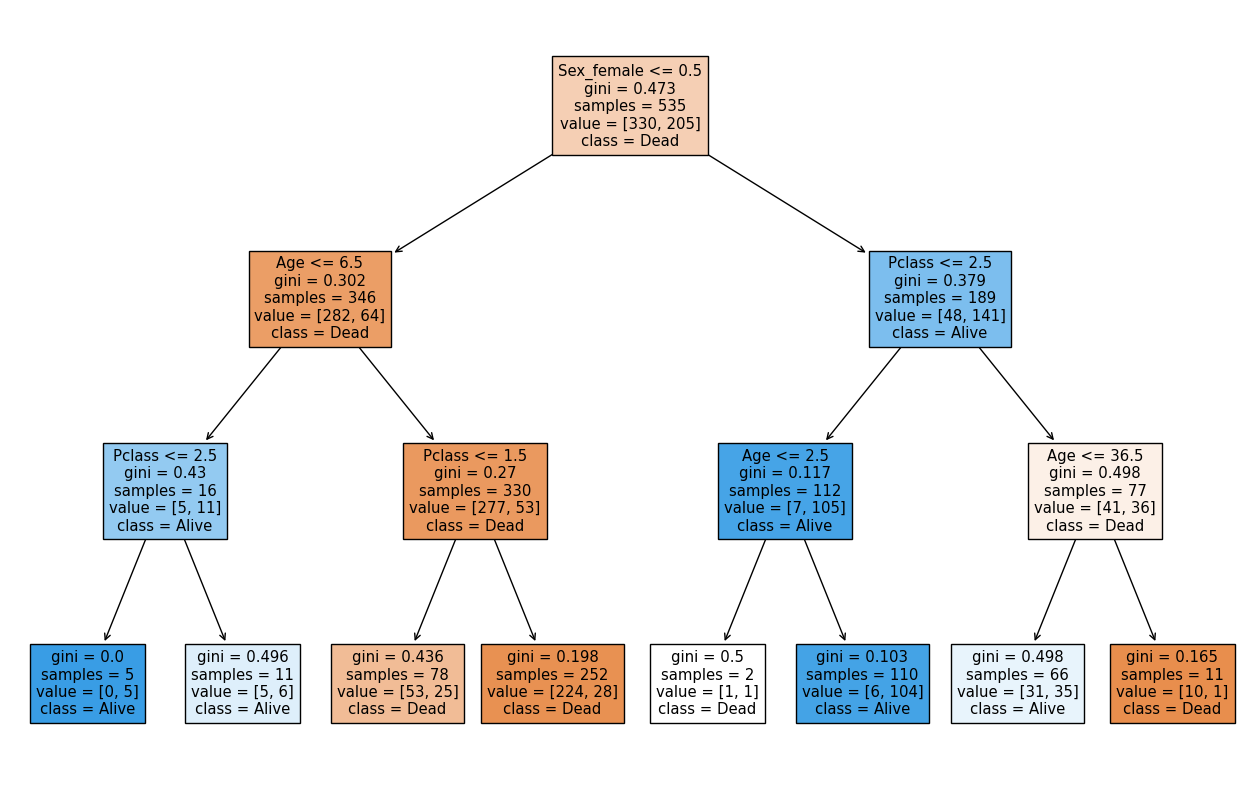

In [23]:
plt.figure(figsize=(16,10))  # bestem hvor stor figure skal være
tree.plot_tree(model, max_depth=3, feature_names=X_train.columns, class_names=["Dead", "Alive"], filled=True)
plt.show()

Her er Gemini sin forklaring som er langt bedre formulerte enn noe jeg kunne klart:)

1. Slik navigerer du i treet
Du starter alltid i den øverste boksen (kalt "rotnoden") og jobber deg nedover.

Hvis betingelsen på toppen av en boks er SANN (True), følger du pilen ned til venstre.

Hvis betingelsen er USANN (False), følger du pilen ned til høyre.

2. Hva betyr teksten i boksene (nodene)?
La oss ta den aller øverste boksen som et eksempel for å bryte ned informasjonen:

Sex_female <= 0.5 (Betingelsen): Dette er spørsmålet modellen stiller. Kjønnet er slik at 1 er kvinne og 0 er mann.

gini = 0.482: Dette er et mål på hvor "uren" eller blandet noden er (Gini impurity). En verdi på 0.0 betyr at noden er helt ren (alle personene her tilhører samme klasse). Målet til modellen er å få denne verdien så nær null som mulig nedover i treet.

samples = 535: Dette forteller deg hvor mange datapunkter (passasjerer i treningsdataen) som har havnet i akkurat denne boksen. I starten er alle 535 passasjerene her.

value = [318, 217]: Dette er fasiten for passasjerene i boksen. Her betyr det at av de 535 passasjerene, tilhører 318 den ene klassen (Dead) og 217 den andre (Alive).

class = Dead: Dette er maskinens prediksjon hvis den måtte ta et valg akkurat her. Den velger ganske enkelt den klassen det er flest av i value (siden 318 > 217).

d) 

Vi skal nå teste effekten av ulike dybder av treet. Dette kan gjøres ved å trene opp modeller ved ulike dybder og teste dem, for så å plotte scoren. 

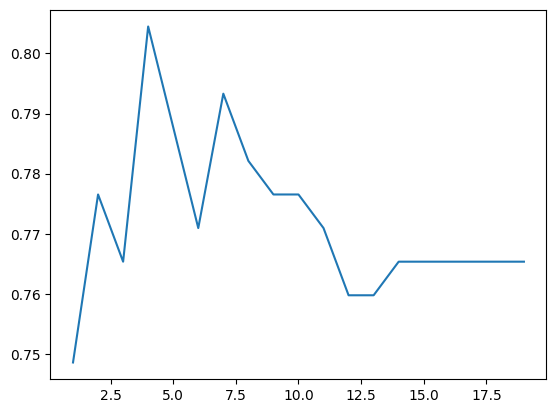

In [ ]:
depths = range(1, 20)     # bestem hvilke dybder vi skal teste: gir en liste [1,2,3,...,19,20]

correct_rate_list = []    # lag en tom liste for å putte resultatene i

for depth in depths:   # loop igjennom elementene i depths
    # tren en model
    model = DecisionTreeClassifier(max_depth=depth, random_state=1)
    model.fit(X_train, y_train)

    pred = model.predict(X_test) # prediker med modellen
    score = np.count_nonzero(pred == y_test) / len(X_test) # beregn andelen riktige
    correct_rate_list.append(score) # legg det til i listen

plt.plot(depths, correct_rate_list) # plot resultatet